# CAPPIMU Data Read


## DATA

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os

# Set up paths
data_dir = Path('../data/raw/CAPPIMU/data')
subject_id = 1

def read_subject_trial(subject_id, data_dir=data_dir):
    """
    Read all sensor data files for a given subject.
    
    Parameters:
    -----------
    subject_id : int
        Subject ID (e.g., 1, 2, 3, ...)
    data_dir : Path
        Base directory containing subject folders
        
    Returns:
    --------
    dict : Dictionary with sensor names as keys and DataFrames as values
    """
    subject_path = data_dir / f'subject_{subject_id}'
    
    # Better error message with actual path
    if not subject_path.exists():
        print(f"❌ Subject path not found: {subject_path.absolute()}")
        print(f"Available subjects: {[d.name for d in data_dir.glob('subject_*') if d.is_dir()]}")
        raise ValueError(f"Subject {subject_id} data not found")
    
    print(f"✓ Found subject directory: {subject_path}")
    
    # Common sensor files
    sensor_files = [
        'chest', 'arm_l', 'arm_r', 'head', 'knee_l', 'knee_r',
        'pocket', 'wrist_l', 'wrist_r', 'insole'
    ]
    
    # Read all available sensor files
    subject_data = {}
    for sensor in sensor_files:
        csv_path = subject_path / f'{sensor}.csv'
        if csv_path.exists():
            try:
                df = pd.read_csv(csv_path)
                subject_data[sensor] = df
                print(f"✓ Loaded {sensor}.csv: {len(df)} rows, {len(df.columns)} columns")
            except Exception as e:
                print(f"⚠️ Error reading {sensor}.csv: {e}")
    
    # Check for insole_ankle
    insole_ankle_path = subject_path / 'insole_ankle.csv'
    if insole_ankle_path.exists():
        try:
            df = pd.read_csv(insole_ankle_path)
            subject_data['insole_ankle'] = df
            print(f"✓ Loaded insole_ankle.csv: {len(df)} rows, {len(df.columns)} columns")
        except Exception as e:
            print(f"⚠️ Error reading insole_ankle.csv: {e}")
    
    # Read joint data if available
    joint_dir = subject_path / 'joint'
    if joint_dir.exists():
        joint_files = list(joint_dir.glob('*.csv'))
        for joint_file in joint_files:
            try:
                df = pd.read_csv(joint_file)
                joint_name = joint_file.stem
                subject_data[f'joint_{joint_name}'] = df
                print(f"✓ Loaded joint/{joint_name}.csv: {len(df)} rows, {len(df.columns)} columns")
            except Exception as e:
                print(f"⚠️ Error reading joint/{joint_name}.csv: {e}")
    
    # Warn if no data was loaded
    if not subject_data:
        print(f"⚠️ No sensor files found in {subject_path}")
        print(f"Files in directory: {list(subject_path.glob('*.csv'))}")
    
    return subject_data

# Read subject trial data
print(f"Reading data for subject {subject_id}...")
print(f"Data directory: {data_dir.absolute()}\n")

try:
    subject_data = read_subject_trial(subject_id)
    
    print(f"\n{'='*50}")
    print(f"Total sensors loaded: {len(subject_data)}")
    print(f"Sensor names: {list(subject_data.keys())}")
    
    # Display basic info about insole specifically (since you mentioned it)
    if 'insole' in subject_data:
        print(f"\n{'='*50}")
        print(f"INSOLE DATA PREVIEW:")
        print(f"{'='*50}")
        print(subject_data['insole'].head())
        print(f"\nShape: {subject_data['insole'].shape}")
        print(f"Columns: {list(subject_data['insole'].columns)}")
        print(f"\nData types:\n{subject_data['insole'].dtypes}")
        print(f"\nMissing values:\n{subject_data['insole'].isnull().sum()}")
    else:
        print("\n⚠️ No insole data found!")
        
except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\nTroubleshooting tips:")
    print("1. Check if the data path exists")
    print("2. Verify subject_id is correct")
    print("3. Ensure CSV files are in the expected location")


Reading data for subject 1...
Data directory: c:\Users\monya\fall-prediction-cappimu\notebooks\..\data\raw\CAPPIMU\data

✓ Found subject directory: ..\data\raw\CAPPIMU\data\subject_1
✓ Loaded chest.csv: 201852 rows, 11 columns
✓ Loaded arm_l.csv: 202738 rows, 11 columns
✓ Loaded arm_r.csv: 204889 rows, 11 columns
✓ Loaded head.csv: 205323 rows, 11 columns
✓ Loaded knee_l.csv: 203514 rows, 11 columns
✓ Loaded knee_r.csv: 200993 rows, 11 columns
✓ Loaded pocket.csv: 204265 rows, 11 columns
✓ Loaded wrist_l.csv: 201265 rows, 11 columns
✓ Loaded wrist_r.csv: 204611 rows, 11 columns
✓ Loaded insole.csv: 203655 rows, 18 columns
✓ Loaded joint/insole_arm_l.csv: 206743 rows, 27 columns
✓ Loaded joint/insole_arm_r.csv: 208692 rows, 27 columns
✓ Loaded joint/insole_chest.csv: 205016 rows, 27 columns
✓ Loaded joint/insole_head.csv: 205992 rows, 27 columns
✓ Loaded joint/insole_knee_l.csv: 202753 rows, 27 columns
✓ Loaded joint/insole_knee_r.csv: 204964 rows, 27 columns
✓ Loaded joint/insole_pocke

In [3]:
# Access the insole data (or change to another sensor if needed)
data = subject_data['insole']

print(data.columns)
print(data.dtypes)


Index(['time', 'insole_l(p1)', 'insole_l(p2)', 'insole_l(p3)', 'insole_l(p4)',
       'insole_l(p5)', 'insole_l(p6)', 'insole_l(p7)', 'insole_l(p8)',
       'insole_r(p1)', 'insole_r(p2)', 'insole_r(p3)', 'insole_r(p4)',
       'insole_r(p5)', 'insole_r(p6)', 'insole_r(p7)', 'insole_r(p8)',
       'label'],
      dtype='object')
time            float64
insole_l(p1)    float64
insole_l(p2)    float64
insole_l(p3)    float64
insole_l(p4)    float64
insole_l(p5)    float64
insole_l(p6)    float64
insole_l(p7)    float64
insole_l(p8)    float64
insole_r(p1)    float64
insole_r(p2)    float64
insole_r(p3)    float64
insole_r(p4)    float64
insole_r(p5)    float64
insole_r(p6)    float64
insole_r(p7)    float64
insole_r(p8)    float64
label            object
dtype: object


In [4]:
print(data['label'].unique())
print(data['label'].value_counts())


['brushing_teeth' 'wash_face' 'cut' 'eat' 'wash_dish' 'use_computer'
 'play_phone' 'folding_clothes' 'write' 'cycle' 'walk' 'run' 'fall'
 'sweep' 'mop' 'wc' 'wash_window' 'drink' 'watch_tv' 'hang_out_clothes'
 'ironing']
label
folding_clothes     13182
use_computer        12321
wash_face           11865
brushing_teeth      10798
walk                10593
wash_dish           10320
write                9987
mop                  9676
wash_window          9620
sweep                9551
cycle                9463
wc                   9455
watch_tv             9392
drink                9322
hang_out_clothes     9289
eat                  9286
play_phone           8812
cut                  8550
fall                 8215
ironing              7757
run                  6201
Name: count, dtype: int64


In [5]:
data['fall_binary'] = (data['label'] == 'fall').astype(int)

print(data['fall_binary'].value_counts())


fall_binary
0    195440
1      8215
Name: count, dtype: int64


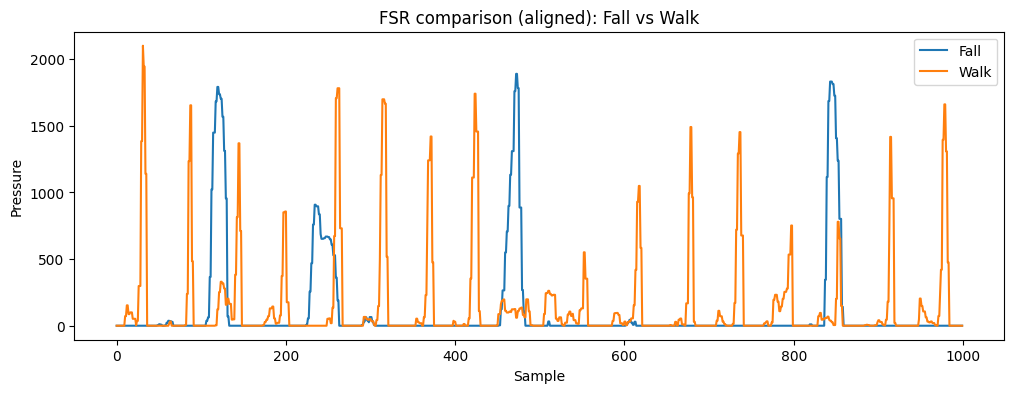

In [9]:
plt.figure(figsize=(12,4))

plt.plot(
    np.arange(len(fall_data.iloc[:1000])),
    fall_data['insole_l(p1)'].iloc[:1000],
    label='Fall'
)

plt.plot(
    np.arange(len(walk_data.iloc[:1000])),
    walk_data['insole_l(p1)'].iloc[:1000],
    label='Walk'
)

plt.legend()
plt.title("FSR comparison (aligned): Fall vs Walk")
plt.xlabel("Sample")
plt.ylabel("Pressure")
plt.show()



FSR signals during walking exhibit periodic, sustained pressure corresponding to gait cycles. In contrast, fall events show abrupt pressure spikes followed by rapid loss of contact, suggesting that temporal pressure dynamics are informative for fall detection.

In [11]:
print(data['time'].head(10))
print(data['time'].tail(10))
print(data['time'].nunique())
print(data['time'].dtype)



0    1.668425e+12
1    1.668425e+12
2    1.668425e+12
3    1.668425e+12
4    1.668425e+12
5    1.668425e+12
6    1.668425e+12
7    1.668425e+12
8    1.668425e+12
9    1.668425e+12
Name: time, dtype: float64
203645    1.679144e+12
203646    1.679144e+12
203647    1.679144e+12
203648    1.679144e+12
203649    1.679144e+12
203650    1.679144e+12
203651    1.679144e+12
203652    1.679144e+12
203653    1.679144e+12
203654    1.679144e+12
Name: time, dtype: float64
203012
float64


In [12]:
FS = 100  # Hz (standard wearable sensing rate)
data['sample_idx'] = np.arange(len(data))

FS = 100          # assumed
WINDOW_SEC = 2.0
STEP_SEC = 1.0

WINDOW_SIZE = int(FS * WINDOW_SEC)
STEP_SIZE = int(FS * STEP_SEC)


Although a timestamp column was provided, multiple sensor samples shared identical timestamps, preventing reliable estimation of sampling frequency. A fixed sampling rate of 100 Hz was therefore assumed, consistent with prior wearable sensing datasets.